### Architecture
In this experiment, Instead of Efficient, SWIN transformer and gbdt predictions are combined through late fusion. Both the models trained on 4 folds and validated on 1 fold, at the end all the OOF predictions are saved and in the fusion stage, both models predictions are combined to get the final output
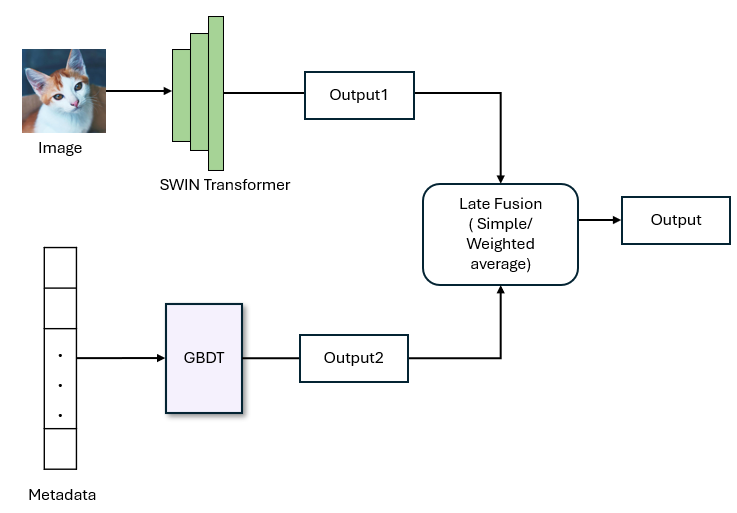
### Analysis of Early Fusion(SWIN+MLP) and Late Fusion(SWIN+GBDT)
Early fusion(SWIN+metadata MLP) and late fusion
(SWIN+ GBDT_late) have very sligh difference. This shows that the fusion method does not help much, since the metadata has little useful information.

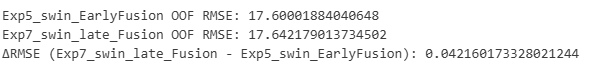

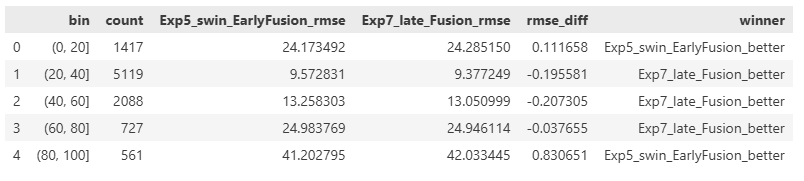

### Analysis of SWIN No Fusion and Late Fusion (swin+GBDT)
The performance difference between Swin + GBDT (late fusion) and Swin-only is very small, indicating that metadata does not add much useful information.

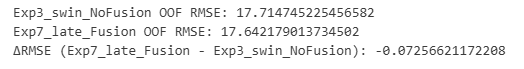

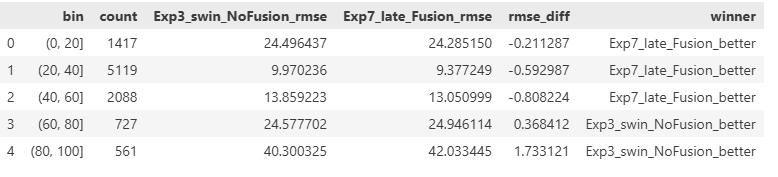

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import os
import sys
sys.path.insert(0, os.path.abspath(".."))

In [4]:
#  imports & setup
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import gc
import time

gc.enable()

import torch
from torch.utils.data import DataLoader
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error
from src.train import run_single_fold

from src.config import EXP_CONFIGS
from src.utils import set_seed, save_config
from src.data import build_transforms, ImageOnlyDataset
from src.models import build_vision_backbone
from src.train import train_one_epoch_image, validate_image



main_folder = ".."
data_csv = os.path.join(main_folder, "data", "train.csv")
img_folder = os.path.join(main_folder, "data", "train")
out_dir = os.path.join(main_folder, "outputs", "exp7")

df = pd.read_csv(data_csv)

TARGET = "Pawpularity"
tab_cols = [c for c in df.columns if c not in ["Id", TARGET]]

os.makedirs(out_dir, exist_ok=True)
set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


/home/ghias/miniconda3/envs/rapids-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
import pandas as pd
import numpy as np
from sklearn.metrics import root_mean_squared_error

# paths
main_folder = ".."
img_oof_path  = os.path.join(main_folder, "outputs", "exp3", "oof_detail.csv")
gbdt_oof_path = os.path.join(main_folder, "outputs", "exp1", "oof_detail.csv")  

img_oof  = pd.read_csv(img_oof_path)   # columns: Id, fold, ytrue, oof_pred, abs_err
gbdt_oof = pd.read_csv(gbdt_oof_path)  # same columns



In [6]:
# check for alignment of Ids and folds
img_map = img_oof[["Id", "fold"]].sort_values("Id").reset_index(drop=True)
gbdt_map = gbdt_oof[["Id", "fold"]].sort_values("Id").reset_index(drop=True)

assert img_map.equals(gbdt_map), "Fold assignment differs! RMSE per fold will be wrong."


In [7]:
assert set(img_oof["Id"]) == set(gbdt_oof["Id"]), "IDs differ!"

In [8]:

# inner join on Id to  alignment
oof = img_oof.merge(
    gbdt_oof[["Id", "oof_pred"]].rename(columns={"oof_pred": "gbdt_oof"}),
    on="Id",
    how="inner",
)

y_true = oof["ytrue"].values
img_pred = oof["oof_pred"].values
gbdt_pred = oof["gbdt_oof"].values

In [9]:
img_rmse = root_mean_squared_error(y_true, img_pred)
gbdt_rmse = root_mean_squared_error(y_true, gbdt_pred)
print("Image OOF RMSE:", img_rmse)
print("GBDT OOF RMSE:", gbdt_rmse)

Image OOF RMSE: 17.714745225456582
GBDT OOF RMSE: 20.668644721159303


### simple average

In [ ]:
from src.utils import late_fusion_from_oof

# oof
oof_fused, oof_rmse, info = late_fusion_from_oof(
    oof,
    img_col="oof_pred",
    tab_col="gbdt_oof",
    y_col="ytrue",
    fold_col="fold",
    mode="simple",      # or "simple" | "weighted", simple is just average 
)

print("Global OOF RMSE:", oof_rmse)
print("Weights:", info["weight_a"], info["weight_b"])
print("Fold-wise RMSE:", info["fold_rmse"])
print("Avg:", info["fold_rmse_mean"], "Std:", info["fold_rmse_std"])

oof_fused = oof_fused.rename(columns={"oof_pred": "swin_oof"})

# save new OOF 
oof_fused.to_csv(os.path.join(main_folder, "outputs", "exp7", "swin_GBDT_average_oof_detail.csv"),
                 index=False)



Global OOF RMSE: 18.227740780156775
Weights: 0.5 0.5
Fold-wise RMSE: {1: 18.644948041668254, 2: 18.31577504400098, 3: 17.7325126915345, 4: 18.126731357075176, 5: 18.306315466975974}
Avg: 18.225256520250973 Std: 0.29779483462699163


### weighted average

In [11]:
oof_fused, oof_rmse, info = late_fusion_from_oof(
    oof,
    img_col="oof_pred",
    tab_col="gbdt_oof",
    y_col="ytrue",
    fold_col="fold",
    mode="weighted",      # or "simple" | "weighted", simple is just average 
    n_grid=101,
)

print("Global OOF RMSE:", oof_rmse)
print("Weights:", info["weight_a"], info["weight_b"])
print("Fold-wise RMSE:", info["fold_rmse"])
print("Avg:", info["fold_rmse_mean"], "Std:", info["fold_rmse_std"])

oof_fused = oof_fused.rename(columns={"oof_pred": "swin_oof"})
oof_fused["abs_err"] = (oof_fused["ytrue"] - oof_fused["final_pred"]).abs()
# save new OOF 
oof_fused.to_csv(os.path.join(main_folder, "outputs", "exp7", "swin_GBDT_weighted_oof_detail.csv"),
                 index=False)
oof_fused.sort_values("abs_err", ascending=False).head(50).to_csv(
    os.path.join(main_folder, "outputs", "exp7",  "swin_GBDT_top50_errors.csv"), index=False
)

Global OOF RMSE: 17.642179013734502
Weights: 0.87 0.13
Fold-wise RMSE: {1: 17.919611808486625, 2: 17.86129318939476, 3: 17.095649160465026, 4: 17.457376749589695, 5: 17.862362498238404}
Avg: 17.6392586812349 Std: 0.31820272156780477


In [12]:
oof_detailed = oof_fused.copy()
oof_detailed = oof_detailed.rename(columns={"final_pred": "oof_pred"})
oof_detailed.to_csv(os.path.join(main_folder, "outputs", "exp7", "oof_detail.csv"),
                 index=False)

In [13]:
import pandas
df = pd.read_csv(out_dir+"/swin_GBDT_weighted_oof_detail.csv")

for fold in range(1, 6):
    sub = df[df.fold == fold]
    rmse = ((sub.ytrue - sub.final_pred)**2).mean() ** 0.5
    print(f"Fold {fold} OOF RMSE: {rmse:.4f} (n={len(sub)})")

Fold 1 OOF RMSE: 17.9196 (n=1983)
Fold 2 OOF RMSE: 17.8613 (n=1983)
Fold 3 OOF RMSE: 17.0956 (n=1982)
Fold 4 OOF RMSE: 17.4574 (n=1982)
Fold 5 OOF RMSE: 17.8624 (n=1982)


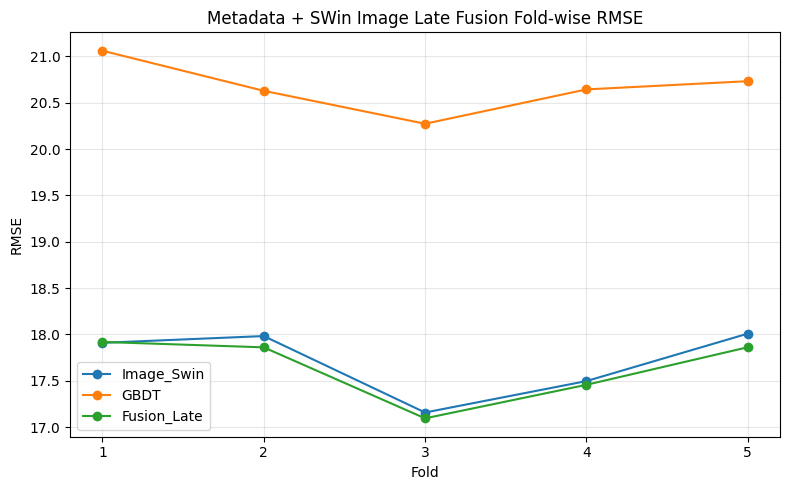

In [14]:
from src.plot import plot_foldwise_rmse
df = pd.read_csv(out_dir + "/swin_GBDT_weighted_oof_detail.csv")

rmse_results = plot_foldwise_rmse(
    df,
    y_col="ytrue",
    pred_cols={
        "Image_Swin": "swin_oof",
        "GBDT": "gbdt_oof",
        "Fusion_Late": "final_pred"
    },
    fold_col="fold",
    title="Metadata + SWin Image Late Fusion Fold-wise RMSE",
)





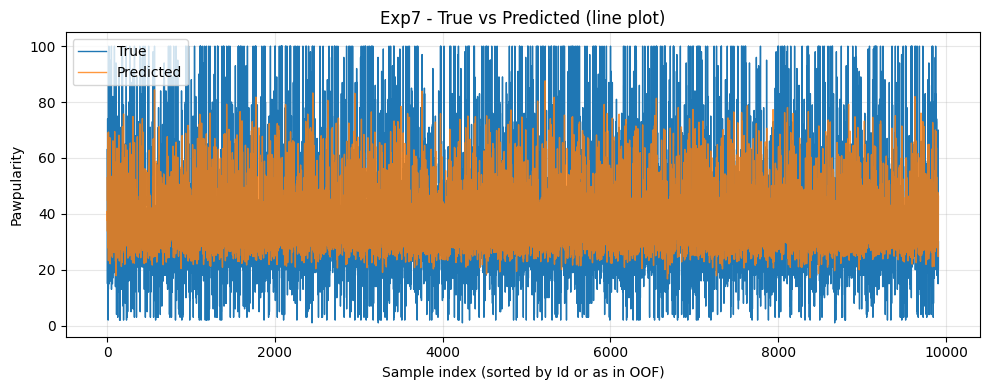

In [15]:
import os
import pandas as pd
from src.plot import (
   plot_oof_true_pred_lines,
    show_images_grid,
)

oof_df = df.rename(columns={"final_pred": "oof_pred"})


# Plots
plot_oof_true_pred_lines(oof_df, title_prefix="Exp7")

Image Swin OOF RMSE: 17.7147
GBDT OOF RMSE: 20.6686
Late Fusion OOF RMSE: 17.6422


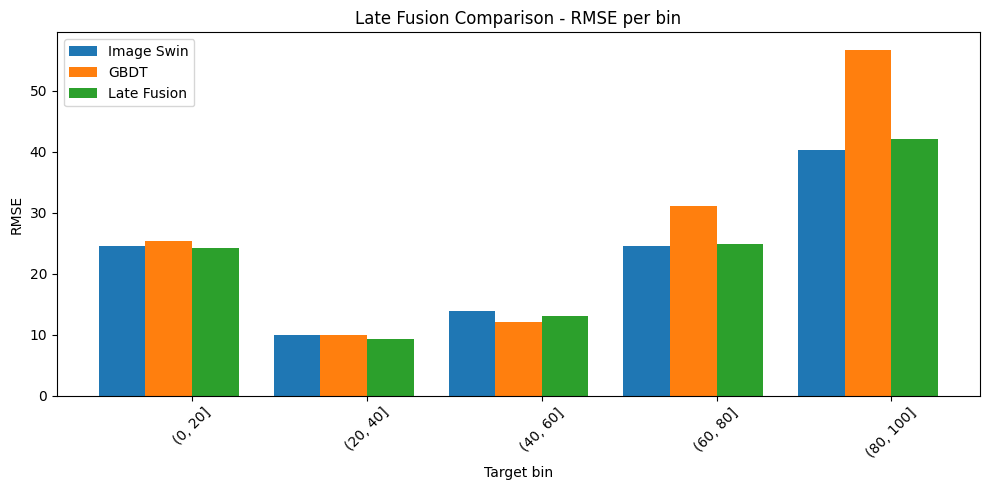

In [16]:
bins = [0, 20, 40, 60, 80, 100]
from src.plot import compare_oof_by_bins_multi

summary, overall = compare_oof_by_bins_multi(
    oof_df,
    bins=bins,
    y_col="ytrue",
    pred_cols={
        "Image Swin": "swin_oof",
        "GBDT": "gbdt_oof",
        "Late Fusion": "oof_pred"
    },
    title_prefix="Late Fusion Comparison"
)

In [17]:
summary.head()

,bin,count,Image Swin_rmse,GBDT_rmse,Late Fusion_rmse
0,"(0, 20]",1417,24.496437,25.400309,24.285150
1,"(20, 40]",5119,9.970236,9.921763,9.377249
2,"(40, 60]",2088,13.859223,12.038565,13.050999
3,"(60, 80]",727,24.577702,31.179264,24.946114
4,"(80, 100]",561,40.300325,56.751675,42.033445


Exp5_swin_EarlyFusion OOF RMSE: 17.60001884040648
Exp7_swin_late_Fusion OOF RMSE: 17.642179013734502
ΔRMSE (Exp7_swin_late_Fusion - Exp5_swin_EarlyFusion): 0.042160173328021244


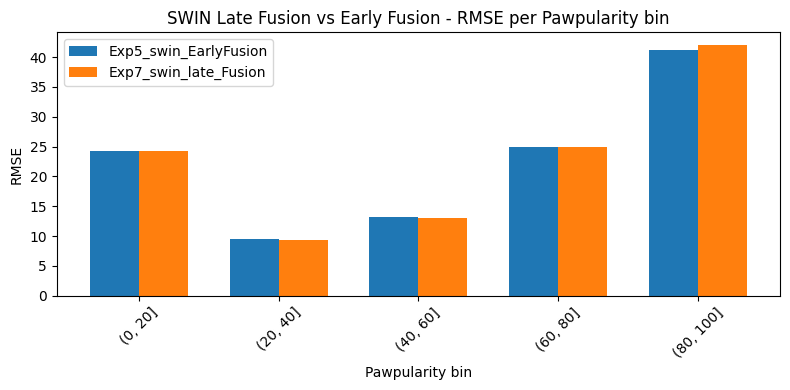

In [26]:
from src.plot import compare_oof_by_bins
bins = [0, 20, 40, 60, 80, 100]

df_bins, rmse3_all, rmse5_all, gap = compare_oof_by_bins(
    oof_path_a="../outputs/exp5/oof_detail.csv",
    oof_path_b="../outputs/exp7/oof_detail.csv",
    bins=bins,
    label_a="Exp5_swin_EarlyFusion",
    label_b="Exp7_swin_late_Fusion",
    title_prefix="SWIN Late Fusion vs Early Fusion",
)

In [19]:
df_bins.head()

,bin,count,Exp5_swin_EarlyFusion_rmse,Exp7_late_Fusion_rmse,rmse_diff,winner
0,"(0, 20]",1417,24.173492,24.285150,0.111658,Exp5_swin_EarlyFusion_better
1,"(20, 40]",5119,9.572831,9.377249,-0.195581,Exp7_late_Fusion_better
2,"(40, 60]",2088,13.258303,13.050999,-0.207305,Exp7_late_Fusion_better
3,"(60, 80]",727,24.983769,24.946114,-0.037655,Exp7_late_Fusion_better
4,"(80, 100]",561,41.202795,42.033445,0.830651,Exp5_swin_EarlyFusion_better


Exp3_swin_NoFusion OOF RMSE: 17.714745225456582
Exp7_late_Fusion OOF RMSE: 17.642179013734502
ΔRMSE (Exp7_late_Fusion - Exp3_swin_NoFusion): -0.07256621172208


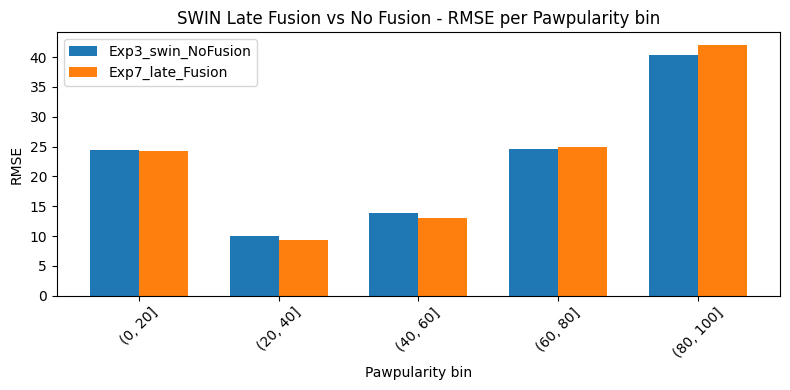

In [20]:
from src.plot import compare_oof_by_bins
bins = [0, 20, 40, 60, 80, 100]

df_bins, rmse3_all, rmse5_all, gap = compare_oof_by_bins(
    oof_path_a="../outputs/exp3/oof_detail.csv",
    oof_path_b="../outputs/exp7/oof_detail.csv",
    bins=bins,
    label_a="Exp3_swin_NoFusion",
    label_b="Exp7_late_Fusion",
    title_prefix="SWIN Late Fusion vs No Fusion",
)

In [21]:
df_bins.head()

,bin,count,Exp3_swin_NoFusion_rmse,Exp7_late_Fusion_rmse,rmse_diff,winner
0,"(0, 20]",1417,24.496437,24.285150,-0.211287,Exp7_late_Fusion_better
1,"(20, 40]",5119,9.970236,9.377249,-0.592987,Exp7_late_Fusion_better
2,"(40, 60]",2088,13.859223,13.050999,-0.808224,Exp7_late_Fusion_better
3,"(60, 80]",727,24.577702,24.946114,0.368412,Exp3_swin_NoFusion_better
4,"(80, 100]",561,40.300325,42.033445,1.733121,Exp3_swin_NoFusion_better


In [22]:
err_df = pd.read_csv(os.path.join(main_folder, "outputs", "exp6",  "Eff_GBDT_top50_errors.csv"))
err_df = err_df.rename(columns={"final_pred": "oof_pred"})

In [23]:
err_df.head()

,Id,fold,ytrue,Eff_oof,abs_err,gbdt_oof,oof_pred
0,e2ae437b18e6ca5261acc713ecda948f,4,100,16.838764,83.161236,42.156914,25.446935
1,b6f886a92a5dd3bdb2d1fb77ffd00848,5,19,99.584068,80.584068,39.870379,79.281414
2,deb8d1618d0cdc2a78c8198b882ebb2b,3,100,20.086704,79.913296,37.726416,26.084206
3,73f9e8a6d0926f7c5201f034406d986d,4,100,20.672062,79.327938,42.643867,28.142476
4,bc39a9c4ae544bfc4118d59b9b089135,4,5,82.860634,77.860634,44.034757,69.659836


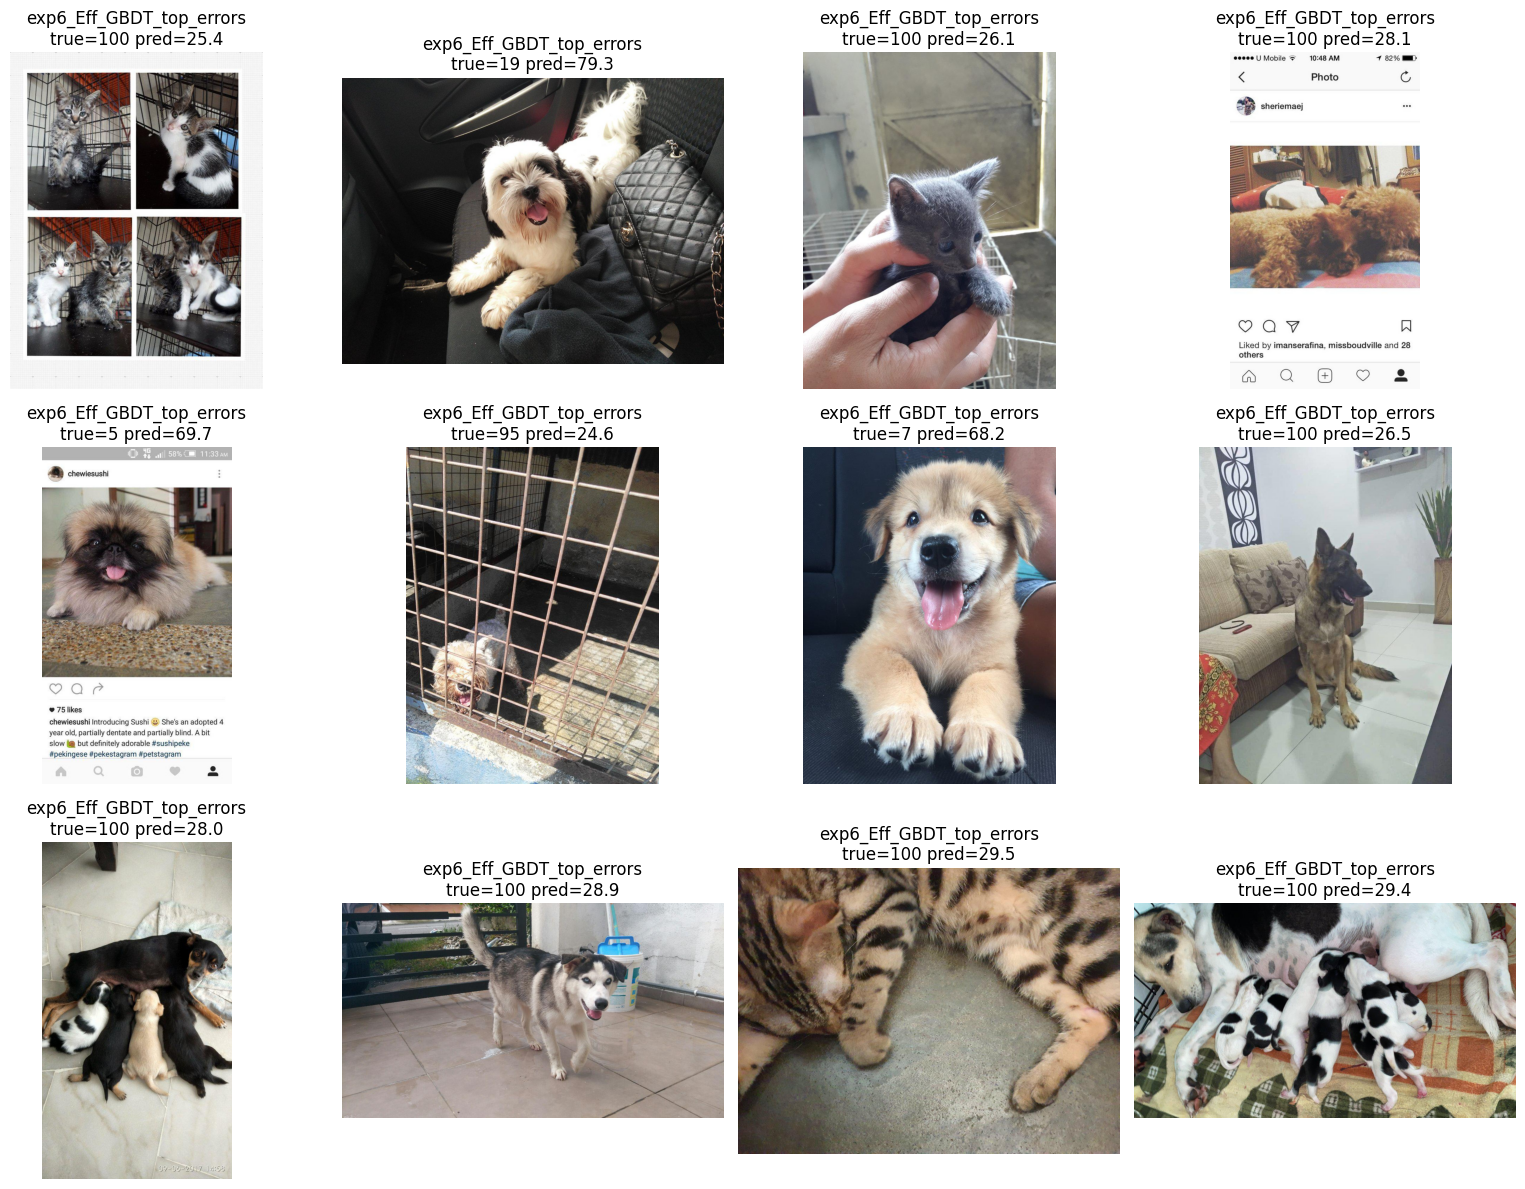

In [24]:
img_folder = os.path.join(main_folder, "data", "train")
show_images_grid(err_df, img_folder, n=12, title_prefix="exp6_Eff_GBDT_top_errors")

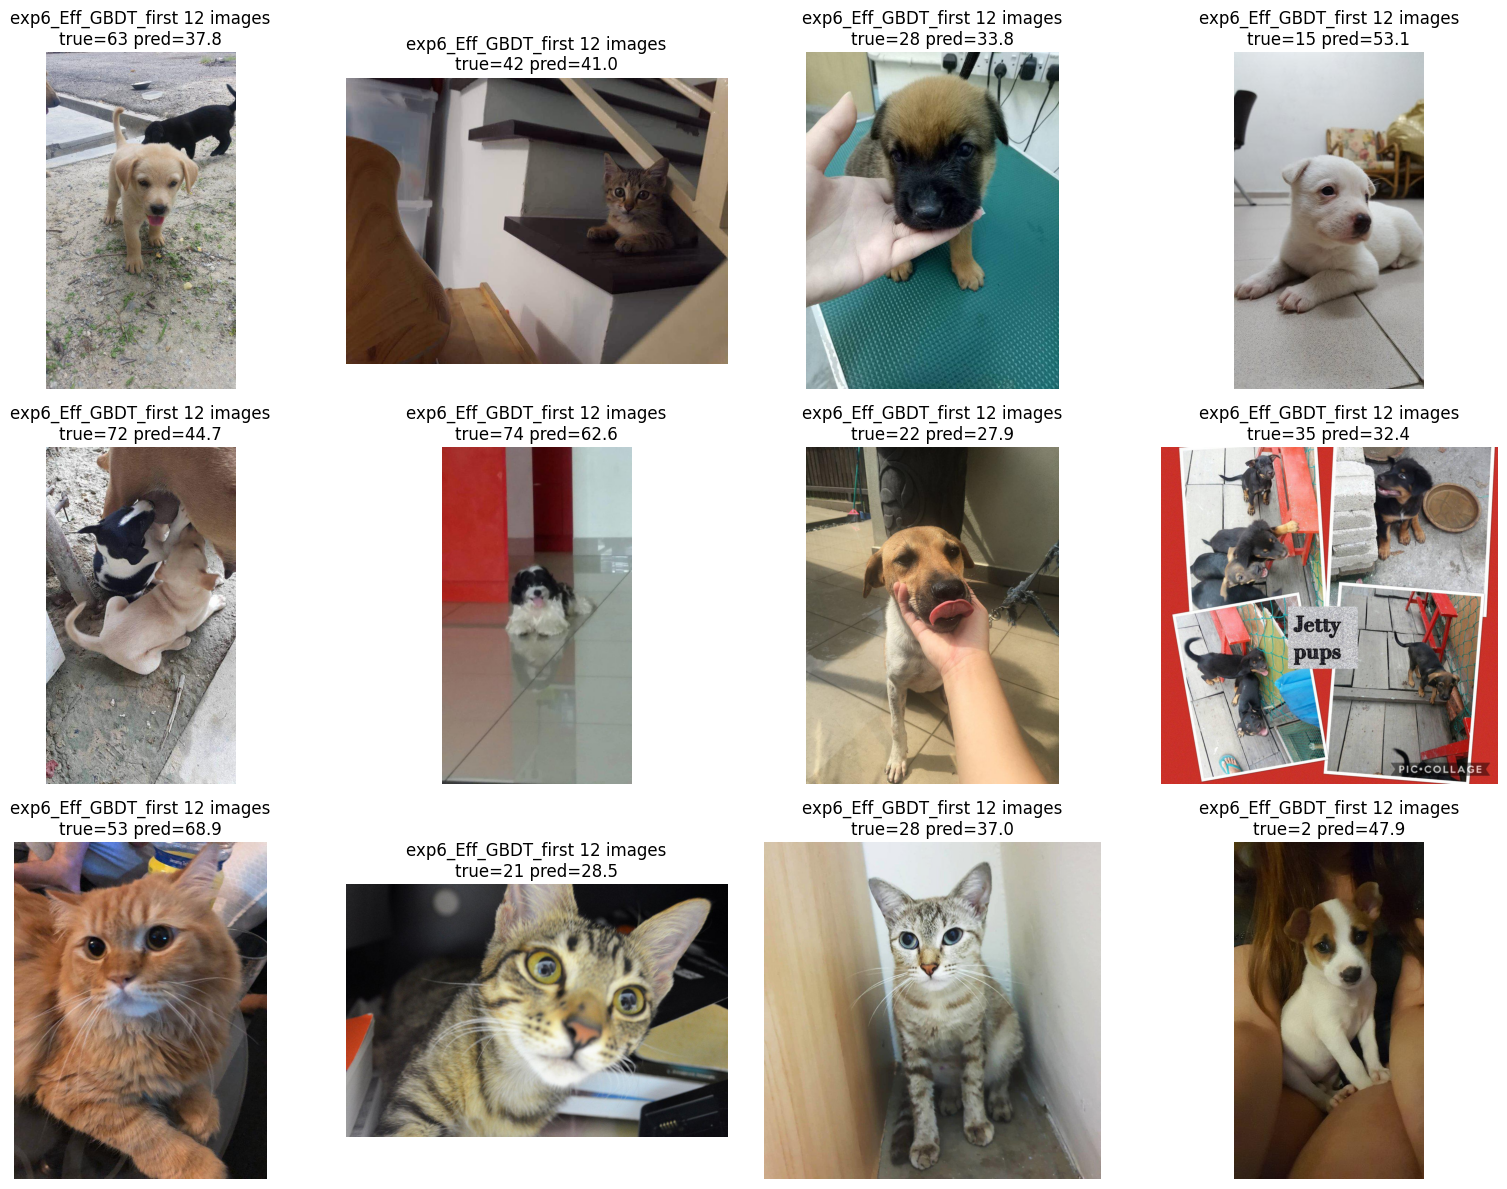

In [25]:
oof_df = oof_df.rename(columns={"final_pred": "oof_pred"})
show_images_grid(oof_df, img_folder, n=12, title_prefix="exp6_Eff_GBDT_first 12 images")